In [25]:
# ============================================================================
# IMPORT STYLED TABLE DISPLAY UTILITIES
# ============================================================================
# Functions are defined in utils/styled_tables.py for reuse across notebooks

import sys, os
sys.path.insert(0, os.path.abspath(os.path.dirname("__file__")))

from utils import display_styled_table, display_table_with_stats, TABLE_COLORS

print("✅ Styled table display functions loaded from utils/styled_tables.py!")
print("   Available functions:")
print("   • display_styled_table(df, title, header_color, ...)")
print("   • display_table_with_stats(df, title, stats_cols, ...)")
print("   • TABLE_COLORS: Predefined color schemes")

✅ Styled table display functions loaded from utils/styled_tables.py!
   Available functions:
   • display_styled_table(df, title, header_color, ...)
   • display_table_with_stats(df, title, stats_cols, ...)
   • TABLE_COLORS: Predefined color schemes


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.api as sms
from scipy.stats import norm
from scipy import stats
from pathlib import Path
from IPython.display import display, HTML
import sys
from scipy import stats as sp_stats
from scipy.stats import gaussian_kde
from scipy.stats import pearsonr
import warnings
warnings.filterwarnings('ignore')

# Display with better formatting - all columns visible
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [27]:
# Gets the parent directory of the current working directory
project_root = Path.cwd().parent.parent
fullpath = "{}/data/VST152/pva_donors.csv".format(project_root)
donor_data = pd.read_csv(fullpath)
donor_data = donor_data.drop(columns=['Rep_DemMedIncome','IM_Rep_DemMedIncome','log_GiftCnt36'])
print(f"Data loaded successfully!")
print(f"Shape: {donor_data.shape}")
display_styled_table(donor_data.head(), title="PVA Donor Data (First 5 Rows)", header_color=TABLE_COLORS['green'])

Data loaded successfully!
Shape: (9686, 28)

PVA Donor Data (First 5 Rows)


ID,GiftCnt36,GiftCntAll,GiftCntCard36,GiftCntCardAll,GiftAvgLast,GiftAvg36,GiftAvgAll,GiftAvgCard36,GiftTimeLast,GiftTimeFirst,PromCnt12,PromCnt36,PromCntAll,PromCntCard12,PromCntCard36,PromCntCardAll,StatusCat96NK,StatusCatStarAll,DemCluster,DemAge,DemGender,DemHomeOwner,DemMedHomeValue,DemPctVeterans,DemMedIncome,Response,Donation_Amt
14974,2.0,4.0,1.0,3.0,17.0,13.50,9.25,17.00,21.0,66.0,8.0,17.0,26.0,3.0,8.0,13.0,A,0.0,0,NaN,F,U,0.0,0.0,0.0,No,NaN
6294,1.0,8.0,0.0,3.0,20.0,20.00,15.88,NaN,26.0,92.0,14.0,35.0,79.0,5.0,5.0,24.0,A,0.0,23,67.0,F,U,186800.0,85.0,0.0,No,NaN
46110,6.0,41.0,3.0,20.0,6.0,5.17,3.73,5.00,18.0,111.0,12.0,23.0,51.0,5.0,11.0,22.0,S,1.0,0,NaN,M,U,87600.0,36.0,38750.0,Yes,55.451774
185937,3.0,12.0,3.0,8.0,10.0,8.67,8.50,8.67,9.0,93.0,14.0,22.0,44.0,2.0,6.0,16.0,E,1.0,0,NaN,M,U,139200.0,27.0,38942.0,Yes,92.103404
29637,1.0,1.0,1.0,1.0,20.0,20.00,20.00,20.00,21.0,21.0,10.0,15.0,13.0,4.0,7.0,6.0,F,0.0,35,53.0,M,U,168100.0,37.0,71509.0,No,NaN


# Model Diagnostics for Donation Amount (Multiple Regression)

## Overview
This notebook performs **comprehensive model diagnostics** for the multiple regression model built in `06_multiple_regression.ipynb`. We examine the model's parameter estimates, predicted vs observed values, residual behavior, influence diagnostics, and residual-by-regressor patterns.

### Learning Objectives
By the end of this notebook, you should be able to:
- Interpret a parameter estimates table (coefficients, standard errors, t-values, p-values, VIF)
- Read an Observed vs Predicted scatter plot and assess model fit visually
- Interpret the 9-panel Fit Diagnostics grid (residuals, leverage, Cook's D, Q-Q plot)
- Identify influential observations using DFFITS
- Diagnose non-linearity or heteroscedasticity from Residual-by-Regressor plots

### Workflow
1. **Data Preparation**: Rebuild the model from Notebook 06 (stepwise AIC selection)
2. **Parameter Estimates Table**: Variable, DF, estimate, std error, t, p-value, VIF
3. **Observed vs Predicted**: Scatter plot of actual vs predicted Donation_Amt
4. **Fit Diagnostics (3×3)**: Residual, RStudent, leverage, Q-Q, Cook's D, histogram, and summary stats
5. **Influence Diagnostics**: DFFITS by observation
6. **Residual by Regressors (Set 1)**: GiftCnt36, GiftAvgLast, GiftAvg36, GiftAvgAll, GiftTimeLast, GiftTimeFirst
7. **Residual by Regressors (Set 2)**: PromCntCard12, PromCntCard36, PromCntCardAll, StatusCatStarAll_0, StatusCatStarAll_1, StatusCat96NK_A
8. **Residual by Regressors (Set 3)**: StatusCat96NK_E, StatusCat96NK_F, StatusCat96NK_L, StatusCat96NK_N, StatusCat96NK_S

## Step 1: Data Preparation — Rebuild the Regression Model

### What we're doing:
- Reproducing the exact data preparation pipeline from Notebook 06
- Running the same forward stepwise selection with AIC
- Fitting the final OLS model so we can extract residuals, leverage, influence measures

### Why it matters:
- Diagnostics are meaningless without the exact same model and data
- We need the fitted model object to compute residuals, hat matrix, Cook's D, DFFITS, VIF

In [28]:
# Step 1: Data Preparation — Rebuild the Regression Model from Notebook 06
from statsmodels.stats.outliers_influence import OLSInfluence, variance_inflation_factor

# --- Data prep (same as 06) ---
df_analysis = donor_data[donor_data['Donation_Amt'].notna()].copy()
df_analysis = df_analysis.drop('ID', axis=1)

categorical_cols = df_analysis.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df_analysis.select_dtypes(include=['int64', 'float64']).columns.tolist()

numeric_categorical = ['DemCluster', 'StatusCatStarAll']
for col in numeric_categorical:
    if col in numeric_cols:
        categorical_cols.append(col)
        numeric_cols.remove(col)

df_clean = df_analysis.dropna()
df_encoded = pd.get_dummies(df_clean, columns=categorical_cols, drop_first=True)

y = df_encoded['Donation_Amt'].astype(float)
X = df_encoded.drop('Donation_Amt', axis=1).astype(float)

# --- Forward stepwise selection with AIC (FAST numpy version) ---
# The pandas-based version is extremely slow because it converts DataFrames
# to numpy arrays thousands of times inside the inner loop. This version
# pre-converts once and uses numpy throughout.

def forward_selection_aic_fast(X_df, y_series):
    """
    Fast forward stepwise selection using AIC.
    Pre-converts to numpy arrays to avoid repeated pandas-to-numpy overhead.
    """
    y_arr = y_series.values.astype(float)
    X_arr = X_df.values.astype(float)
    col_names = list(X_df.columns)
    n = len(y_arr)

    selected_idx = []      # column indices into X_arr
    remaining_idx = list(range(X_arr.shape[1]))

    # Null model (intercept only)
    ones = np.ones((n, 1))
    null_model = sm.OLS(y_arr, ones).fit()
    best_aic = null_model.aic

    step = 0
    while remaining_idx:
        step += 1
        best_feature_idx, best_new_aic = None, best_aic

        # Build current X matrix once
        if selected_idx:
            X_base = np.column_stack([ones, X_arr[:, selected_idx]])
        else:
            X_base = ones

        for feat_idx in remaining_idx:
            X_test = np.column_stack([X_base, X_arr[:, feat_idx]])
            try:
                test_aic = sm.OLS(y_arr, X_test).fit().aic
                if test_aic < best_new_aic:
                    best_new_aic = test_aic
                    best_feature_idx = feat_idx
            except:
                continue

        if best_feature_idx is None:
            break

        selected_idx.append(best_feature_idx)
        remaining_idx.remove(best_feature_idx)
        best_aic = best_new_aic

        if step % 5 == 0 or step <= 3:
            print(f"  Step {step}: Added '{col_names[best_feature_idx]}' (AIC: {best_aic:.2f})")

    selected_names = [col_names[i] for i in selected_idx]
    return selected_names

print("Running forward stepwise selection with AIC (optimized)...")
import time
t0 = time.time()
selected_features = forward_selection_aic_fast(X, y)
elapsed = time.time() - t0
print(f"✅ Selected {len(selected_features)} features in {elapsed:.1f} seconds")
print(f"   Features: {selected_features}")

# --- Fit the final model ---
X_final = sm.add_constant(X[selected_features])
final_model = sm.OLS(y, X_final).fit()

# --- Pre-compute all diagnostic quantities ---
influence = OLSInfluence(final_model)
residuals     = final_model.resid
fitted_values = final_model.fittedvalues
rstudent      = influence.resid_studentized_external
leverage      = influence.hat_matrix_diag
cooks_d       = influence.cooks_distance[0]
dffits_vals   = influence.dffits[0]
std_resid     = residuals / residuals.std()

n = len(y)
p = len(selected_features) + 1  # +1 for intercept

print(f"\n✅ Final model fitted: {n} observations, {p} parameters")
print(f"   R² = {final_model.rsquared:.4f}, Adj R² = {final_model.rsquared_adj:.4f}")
print(f"   AIC = {final_model.aic:.2f}")

Running forward stepwise selection with AIC (optimized)...
  Step 1: Added 'GiftAvg36' (AIC: 27070.40)
  Step 2: Added 'GiftCnt36' (AIC: 26831.43)
  Step 3: Added 'GiftAvgLast' (AIC: 26736.49)
  Step 5: Added 'GiftTimeFirst' (AIC: 26626.29)
  Step 10: Added 'GiftTimeLast' (AIC: 26538.31)
  Step 15: Added 'DemCluster_21' (AIC: 26523.49)
  Step 20: Added 'DemCluster_2' (AIC: 26517.94)
✅ Selected 24 features in 12.0 seconds
   Features: ['GiftAvg36', 'GiftCnt36', 'GiftAvgLast', 'PromCntCard12', 'GiftTimeFirst', 'PromCntCard36', 'GiftAvgAll', 'StatusCat96NK_S', 'StatusCat96NK_E', 'GiftTimeLast', 'DemCluster_19', 'DemCluster_53', 'StatusCat96NK_N', 'DemCluster_17', 'DemCluster_21', 'DemCluster_11', 'DemCluster_22', 'PromCntCardAll', 'StatusCatStarAll_1.0', 'DemCluster_2', 'DemCluster_43', 'DemCluster_13', 'DemCluster_34', 'DemCluster_24']

✅ Final model fitted: 3101 observations, 25 parameters
   R² = 0.5462, Adj R² = 0.5427
   AIC = 26516.03


## Step 2: Parameter Estimates Table

### What we're doing:
- Building a SAS-style parameter estimates table with Variable, Label, DF, Estimate, Std Error, t Value, Pr > |t|, and VIF

### Why it matters:
- **Estimate** tells you the direction and magnitude of each predictor's effect on Donation_Amt
- **t Value / Pr > |t|** tells you whether the effect is statistically significant
- **VIF** (Variance Inflation Factor) flags multicollinearity — VIF > 5 is concerning, VIF > 10 is severe

### How to interpret:
- A positive estimate means the variable increases predicted donation amount
- A VIF near 1 means the variable is nearly independent of other predictors
- Every variable has DF = 1 (one degree of freedom consumed per parameter)

In [29]:
# Step 2: Parameter Estimates Table
print("=" * 120)
print("TABLE 1: PARAMETER ESTIMATES")
print("=" * 120)

# Compute VIF for each predictor (excluding the constant)
vif_values = []
X_vif = X_final.drop('const', axis=1)
for i, col in enumerate(X_vif.columns):
    vif_values.append(variance_inflation_factor(X_vif.values, i))

# Build the parameter estimates table
param_data = []
for i, var in enumerate(final_model.params.index):
    label = 'Intercept' if var == 'const' else var
    vif = 0.0 if var == 'const' else vif_values[i - 1]
    param_data.append({
        'Variable': var,
        'Label': label,
        'DF': 1,
        'Parameter Estimate': round(final_model.params[var], 6),
        'Standard Error': round(final_model.bse[var], 6),
        't Value': round(final_model.tvalues[var], 2),
        'Pr > |t|': round(final_model.pvalues[var], 6),
        'Variance Inflation': round(vif, 2)
    })

param_df = pd.DataFrame(param_data)

display_styled_table(
    param_df,
    title="Parameter Estimates for Donation_Amt",
    header_color=TABLE_COLORS['purple'],
    font_size="11px"
)

# Flag significant variables
print("\n" + "-" * 120)
print("SIGNIFICANCE LEGEND")
print("-" * 120)
print("  *** p < 0.001  |  ** p < 0.01  |  * p < 0.05  |  . p < 0.10")
print("\nVIF THRESHOLDS")
print("  VIF < 5 : No concern  |  5 ≤ VIF < 10 : Moderate  |  VIF ≥ 10 : Severe multicollinearity")

high_vif = param_df[(param_df['Variance Inflation'] >= 5) & (param_df['Variable'] != 'const')]
if len(high_vif) > 0:
    print(f"\n⚠️  {len(high_vif)} variable(s) with VIF ≥ 5:")
    for _, row in high_vif.iterrows():
        print(f"   • {row['Variable']}: VIF = {row['Variance Inflation']:.2f}")
else:
    print("\n✅ No multicollinearity concerns (all VIF < 5)")

TABLE 1: PARAMETER ESTIMATES

Parameter Estimates for Donation_Amt


Variable,Label,DF,Parameter Estimate,Standard Error,t Value,Pr > |t|,Variance Inflation
const,Intercept,1,72.883872,2.964966,24.58,0.000000,0.00
GiftAvg36,GiftAvg36,1,0.561115,0.107030,5.24,0.000000,32.28
GiftCnt36,GiftCnt36,1,-3.039003,0.206636,-14.71,0.000000,8.47
GiftAvgLast,GiftAvgLast,1,0.545361,0.053819,10.13,0.000000,10.12
PromCntCard12,PromCntCard12,1,0.812690,0.440189,1.85,0.064955,48.76
GiftTimeFirst,GiftTimeFirst,1,-0.107693,0.026520,-4.06,0.000050,40.68
PromCntCard36,PromCntCard36,1,0.791385,0.241515,3.28,0.001062,120.29
GiftAvgAll,GiftAvgAll,1,0.488156,0.113650,4.30,0.000018,23.81
StatusCat96NK_S,StatusCat96NK_S,1,-2.629553,0.857521,-3.07,0.002185,2.51
StatusCat96NK_E,StatusCat96NK_E,1,9.343223,3.169959,2.95,0.003228,1.05



------------------------------------------------------------------------------------------------------------------------
SIGNIFICANCE LEGEND
------------------------------------------------------------------------------------------------------------------------
  *** p < 0.001  |  ** p < 0.01  |  * p < 0.05  |  . p < 0.10

VIF THRESHOLDS
  VIF < 5 : No concern  |  5 ≤ VIF < 10 : Moderate  |  VIF ≥ 10 : Severe multicollinearity

⚠️  9 variable(s) with VIF ≥ 5:
   • GiftAvg36: VIF = 32.28
   • GiftCnt36: VIF = 8.47
   • GiftAvgLast: VIF = 10.12
   • PromCntCard12: VIF = 48.76
   • GiftTimeFirst: VIF = 40.68
   • PromCntCard36: VIF = 120.29
   • GiftAvgAll: VIF = 23.81
   • GiftTimeLast: VIF = 13.51
   • PromCntCardAll: VIF = 87.74


In [30]:
# 📊 READOUT: Parameter Estimates — Key Findings
print("=" * 120)
print("📊 READOUT: PARAMETER ESTIMATES — KEY FINDINGS")
print("=" * 120)

# Most significant variables (lowest p-value, excluding intercept)
param_no_const = param_df[param_df['Variable'] != 'const'].copy()
param_no_const['abs_t'] = param_no_const['t Value'].abs()
top_sig = param_no_const.nsmallest(5, 'Pr > |t|')

print("\n  TOP 5 MOST SIGNIFICANT PREDICTORS (by p-value):")
print("  " + "-" * 100)
for _, row in top_sig.iterrows():
    direction = '↑ increases' if row['Parameter Estimate'] > 0 else '↓ decreases'
    sig = '***' if row['Pr > |t|'] < 0.001 else '**' if row['Pr > |t|'] < 0.01 else '*' if row['Pr > |t|'] < 0.05 else ''
    print(f"  {row['Variable']:35s} | Estimate = {row['Parameter Estimate']:10.4f} | t = {row['t Value']:7.2f} | p = {row['Pr > |t|']:.6f} {sig}")
    print(f"  {'':35s}   ➡️  A 1-unit increase {direction} Donation_Amt by ${abs(row['Parameter Estimate']):.4f}")

# Largest positive and negative effects
max_pos = param_no_const.loc[param_no_const['Parameter Estimate'].idxmax()]
max_neg = param_no_const.loc[param_no_const['Parameter Estimate'].idxmin()]

print(f"\n  STRONGEST POSITIVE EFFECT:")
print(f"    {max_pos['Variable']}: estimate = {max_pos['Parameter Estimate']:.4f}")
print(f"    ➡️  Each additional unit of {max_pos['Variable']} adds ${max_pos['Parameter Estimate']:.4f} to predicted donation.")

print(f"\n  STRONGEST NEGATIVE EFFECT:")
print(f"    {max_neg['Variable']}: estimate = {max_neg['Parameter Estimate']:.4f}")
print(f"    ➡️  Each additional unit of {max_neg['Variable']} reduces predicted donation by ${abs(max_neg['Parameter Estimate']):.4f}.")

# VIF summary
max_vif_row = param_no_const.loc[param_no_const['Variance Inflation'].idxmax()]
print(f"\n  MULTICOLLINEARITY:")
print(f"    Highest VIF = {max_vif_row['Variance Inflation']:.2f} ({max_vif_row['Variable']})")
if max_vif_row['Variance Inflation'] >= 10:
    print(f"    🔴 SEVERE: VIF ≥ 10. {max_vif_row['Variable']} is highly correlated with other predictors.")
    print(f"       Its coefficient estimate and standard error are unreliable.")
elif max_vif_row['Variance Inflation'] >= 5:
    print(f"    🟡 MODERATE: 5 ≤ VIF < 10. Some redundancy exists but may be acceptable.")
else:
    print(f"    ✅ All VIF < 5. No multicollinearity concern.")

print(f"\n  INTERCEPT = {final_model.params['const']:.4f}")
print(f"    ➡️  When all predictors are zero, the baseline predicted donation is ${final_model.params['const']:.2f}.")
print(f"       (This is a mathematical baseline; it may not represent a realistic donor profile.)")

📊 READOUT: PARAMETER ESTIMATES — KEY FINDINGS

  TOP 5 MOST SIGNIFICANT PREDICTORS (by p-value):
  ----------------------------------------------------------------------------------------------------
  GiftAvg36                           | Estimate =     0.5611 | t =    5.24 | p = 0.000000 ***
                                        ➡️  A 1-unit increase ↑ increases Donation_Amt by $0.5611
  GiftCnt36                           | Estimate =    -3.0390 | t =  -14.71 | p = 0.000000 ***
                                        ➡️  A 1-unit increase ↓ decreases Donation_Amt by $3.0390
  GiftAvgLast                         | Estimate =     0.5454 | t =   10.13 | p = 0.000000 ***
                                        ➡️  A 1-unit increase ↑ increases Donation_Amt by $0.5454
  GiftAvgAll                          | Estimate =     0.4882 | t =    4.30 | p = 0.000018 ***
                                        ➡️  A 1-unit increase ↑ increases Donation_Amt by $0.4882
  GiftTimeFirst             

## Step 3: Observed vs Predicted Scatter Plot

### What we're doing:
- Plotting actual Donation_Amt (y-axis) against predicted values (x-axis)

### Why it matters:
- A perfect model would place all points on the 45° diagonal line
- Spread around the line shows the magnitude of prediction error
- Systematic patterns (curves, fans) indicate model specification problems

### What to look for:
- Points clustered tightly around the diagonal = good fit
- Fan-shaped spread = heteroscedasticity (variance changes with predicted value)
- Curved pattern = missing non-linear terms

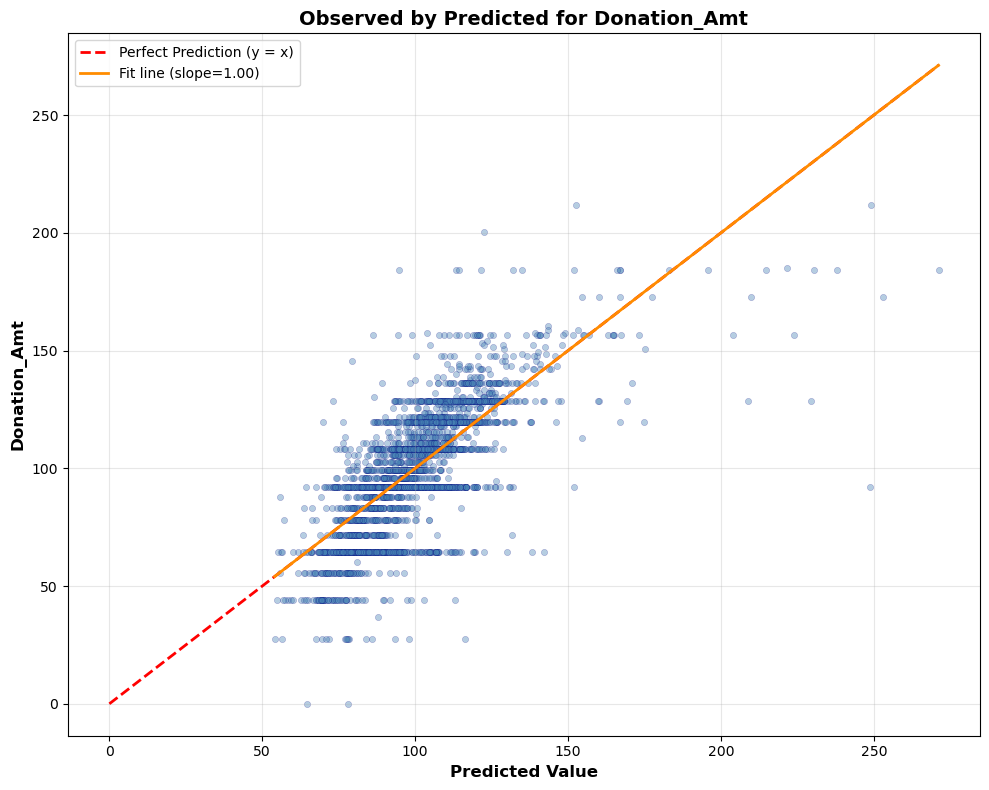


Correlation between observed and predicted: 0.7391
R² = 0.5462


In [31]:
# Step 3: Observed vs Predicted Scatter Plot
fig, ax = plt.subplots(figsize=(10, 8))

ax.scatter(fitted_values, y, alpha=0.4, s=20, color='steelblue', edgecolors='navy', linewidths=0.3)

# 45-degree reference line
min_val = min(fitted_values.min(), y.min())
max_val = max(fitted_values.max(), y.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction (y = x)')

# Fit line through actual data
z = np.polyfit(fitted_values, y, 1)
ax.plot(np.sort(fitted_values), np.polyval(z, np.sort(fitted_values)),
        color='darkorange', linewidth=2, linestyle='-', label=f'Fit line (slope={z[0]:.2f})')

ax.set_xlabel('Predicted Value', fontweight='bold', fontsize=12)
ax.set_ylabel('Donation_Amt', fontweight='bold', fontsize=12)
ax.set_title('Observed by Predicted for Donation_Amt', fontweight='bold', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nCorrelation between observed and predicted: {np.corrcoef(y, fitted_values)[0,1]:.4f}")
print(f"R² = {final_model.rsquared:.4f}")

In [32]:
# 📊 READOUT: Observed vs Predicted Scatter Plot
print("=" * 120)
print("📊 READOUT: OBSERVED VS PREDICTED FOR DONATION_AMT")
print("=" * 120)

corr_obs_pred = np.corrcoef(y, fitted_values)[0, 1]
mae = np.mean(np.abs(residuals))
rmse = np.sqrt(np.mean(residuals ** 2))
medae = np.median(np.abs(residuals))

print(f"\n  Correlation (observed, predicted): {corr_obs_pred:.4f}")
print(f"  R²:                               {final_model.rsquared:.4f}")
print(f"  Mean Absolute Error (MAE):        ${mae:.2f}")
print(f"  Median Absolute Error:            ${medae:.2f}")
print(f"  Root Mean Square Error (RMSE):    ${rmse:.2f}")

print(f"\n  Predicted value range: ${fitted_values.min():.2f}  to  ${fitted_values.max():.2f}")
print(f"  Actual value range:    ${y.min():.2f}  to  ${y.max():.2f}")

# Check for systematic bias
n_over  = (residuals < 0).sum()  # predicted > actual
n_under = (residuals > 0).sum()  # predicted < actual
print(f"\n  Over-predictions  (predicted > actual): {n_over:,} ({n_over/n*100:.1f}%)")
print(f"  Under-predictions (predicted < actual): {n_under:,} ({n_under/n*100:.1f}%)")

print(f"\n  💡 WHAT THIS TELLS YOU:")
print(f"     The model explains {final_model.rsquared*100:.1f}% of the variation in donation amounts.")
print(f"     On average, predictions are off by ${mae:.2f} (half the donors are within ${medae:.2f}).")
print(f"     The fit line slope = {z[0]:.2f} — ", end='')
if abs(z[0] - 1.0) < 0.1:
    print(f"very close to 1.0 (ideal), meaning predictions are well-calibrated.")
else:
    print(f"deviates from 1.0, suggesting the model may systematically")
    if z[0] < 1.0:
        print(f"     compress predictions toward the mean (under-predicts high donors, over-predicts low).")
    else:
        print(f"     over-spread predictions (exaggerates differences).")

📊 READOUT: OBSERVED VS PREDICTED FOR DONATION_AMT

  Correlation (observed, predicted): 0.7391
  R²:                               0.5462
  Mean Absolute Error (MAE):        $12.54
  Median Absolute Error:            $9.60
  Root Mean Square Error (RMSE):    $17.26

  Predicted value range: $54.04  to  $271.14
  Actual value range:    $0.00  to  $211.93

  Over-predictions  (predicted > actual): 1,379 (44.5%)
  Under-predictions (predicted < actual): 1,722 (55.5%)

  💡 WHAT THIS TELLS YOU:
     The model explains 54.6% of the variation in donation amounts.
     On average, predictions are off by $12.54 (half the donors are within $9.60).
     The fit line slope = 1.00 — very close to 1.0 (ideal), meaning predictions are well-calibrated.


## Step 4: Fit Diagnostics for Donation_Amt (3×3 Grid)

### What we're doing:
Creating a 9-panel diagnostic dashboard:

| Panel | Plot | What it checks |
|-------|------|-----------------|
| 1 | Residual vs Predicted Value | Linearity & homoscedasticity |
| 2 | RStudent vs Predicted Value | Outliers (externally studentized residuals) |
| 3 | RStudent vs Leverage | Influential points (high leverage + large residual) |
| 4 | Residual vs Quantile (Q-Q) | Normality of residuals |
| 5 | Donation_Amt vs Predicted Value | Overall model fit |
| 6 | Cook's D vs Observation | Individual observation influence |
| 7 | Percent vs Residual (histogram) | Residual distribution shape |
| 8 | Fit-Mean Residual vs Proportion Less | Residual CDF (empirical distribution) |
| 9 | Summary Statistics Box | Key model metrics at a glance |

### Why it matters:
- **RStudent** (externally studentized residuals) are more sensitive to outliers than raw residuals because each observation's residual is standardized using a model fitted *without* that observation
- **Leverage** measures how far an observation's predictors are from the mean — high-leverage points can disproportionately pull the regression line
- **Cook's D** combines leverage and residual size into a single influence measure

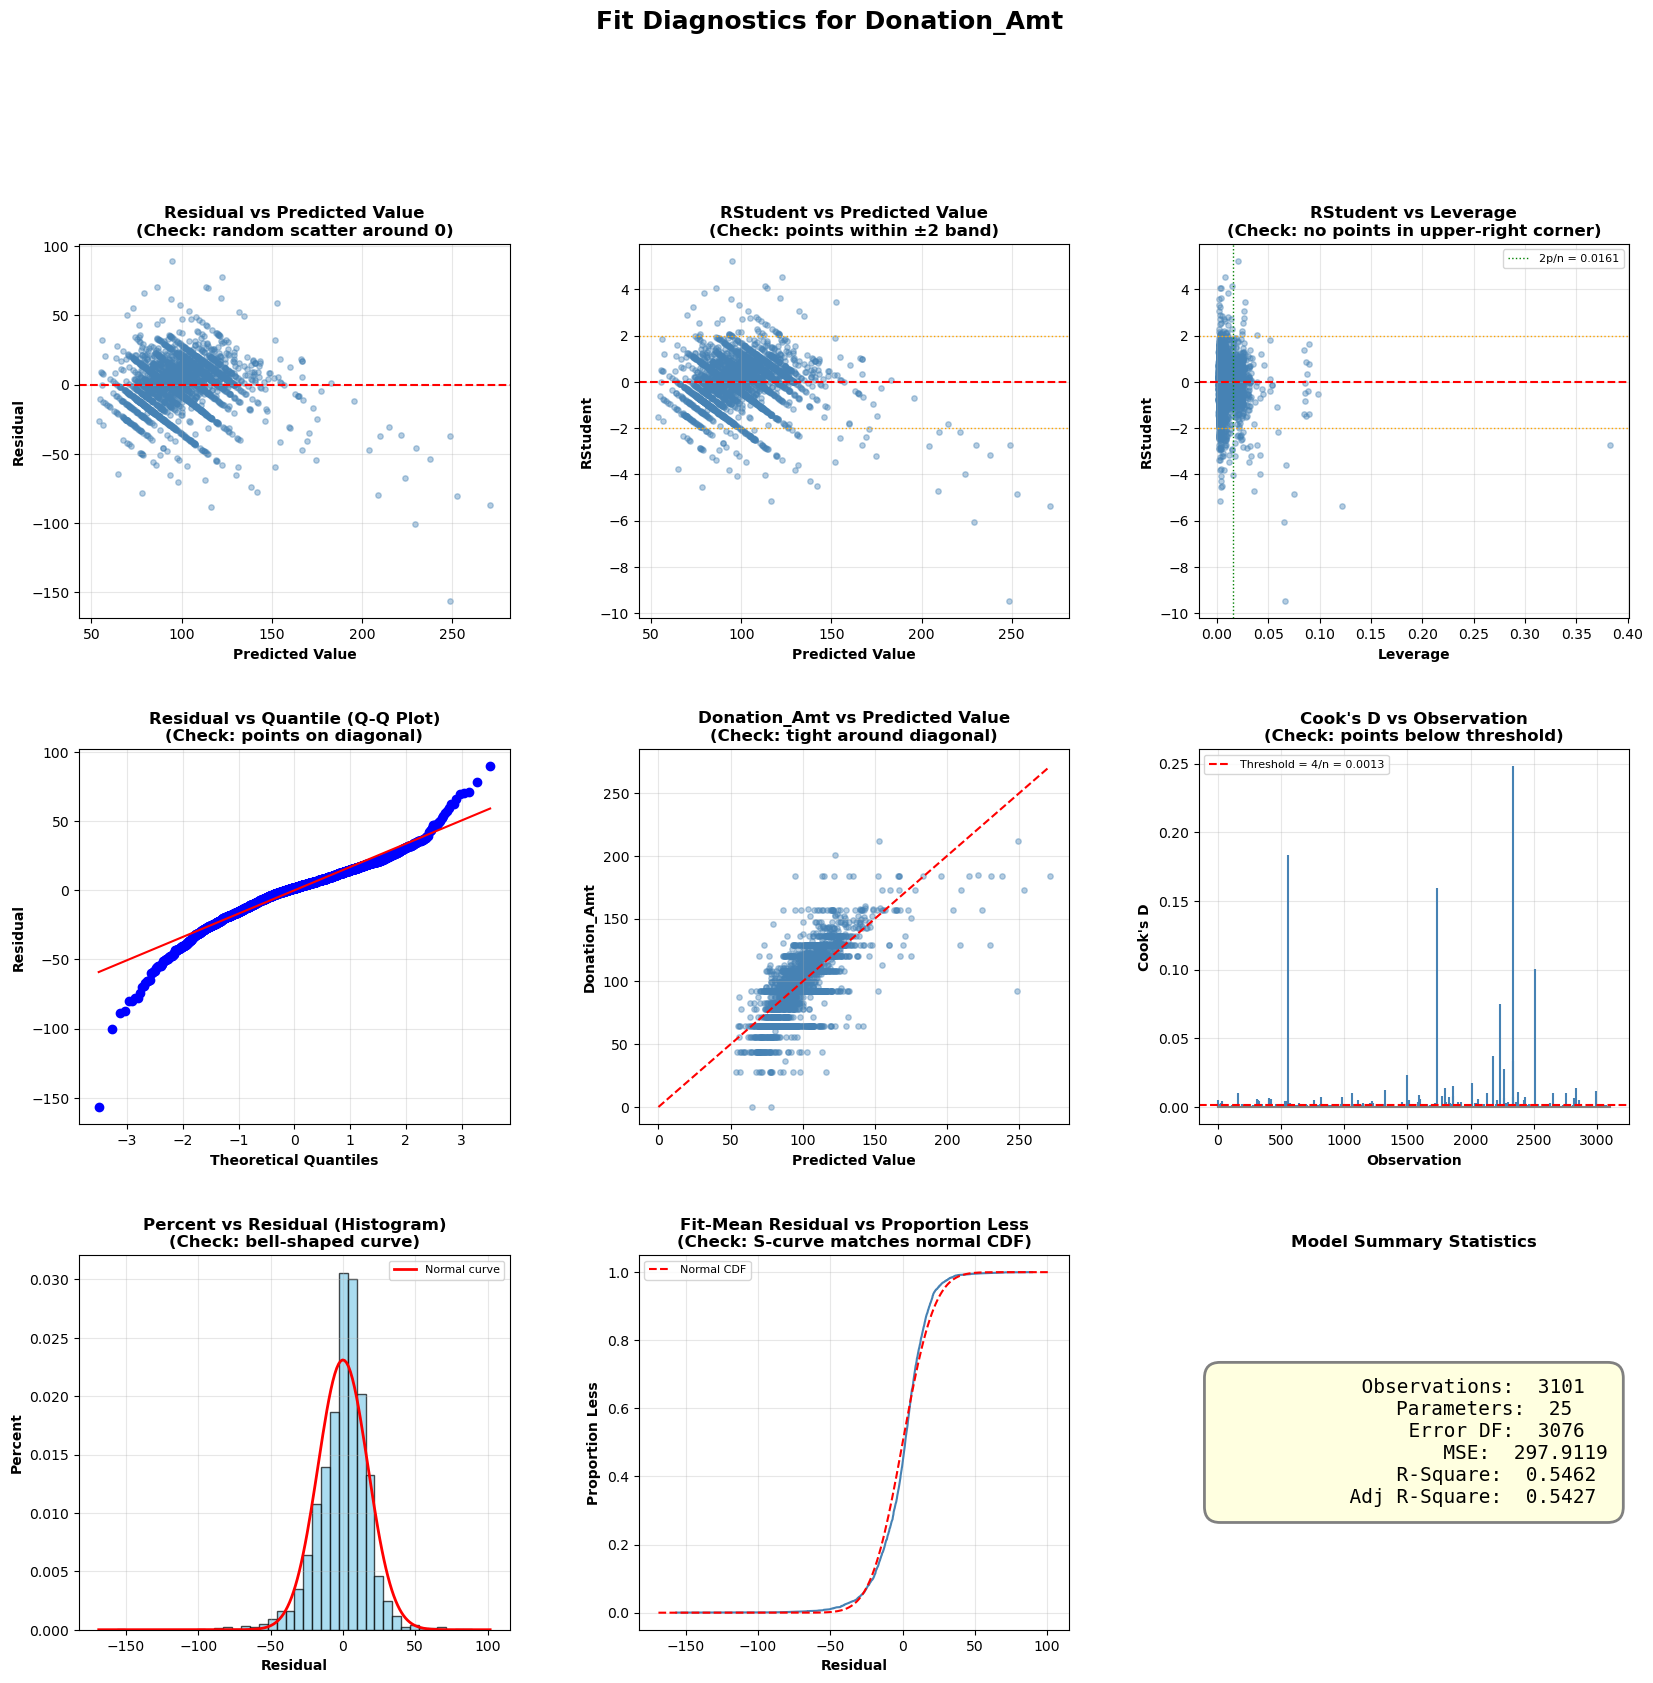

In [33]:
# Step 4: Fit Diagnostics for Donation_Amt (3x3 Grid)
fig = plt.figure(figsize=(20, 18))
fig.suptitle('Fit Diagnostics for Donation_Amt', fontsize=18, fontweight='bold', y=1.01)
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.30)

# --- Panel 1: Residual vs Predicted Value ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.scatter(fitted_values, residuals, alpha=0.4, s=15, color='steelblue')
ax1.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax1.set_xlabel('Predicted Value', fontweight='bold')
ax1.set_ylabel('Residual', fontweight='bold')
ax1.set_title('Residual vs Predicted Value\n(Check: random scatter around 0)', fontweight='bold')
ax1.grid(True, alpha=0.3)

# --- Panel 2: RStudent vs Predicted Value ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(fitted_values, rstudent, alpha=0.4, s=15, color='steelblue')
ax2.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax2.axhline(y=2, color='orange', linestyle=':', linewidth=1)
ax2.axhline(y=-2, color='orange', linestyle=':', linewidth=1)
ax2.set_xlabel('Predicted Value', fontweight='bold')
ax2.set_ylabel('RStudent', fontweight='bold')
ax2.set_title('RStudent vs Predicted Value\n(Check: points within ±2 band)', fontweight='bold')
ax2.grid(True, alpha=0.3)

# --- Panel 3: RStudent vs Leverage ---
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(leverage, rstudent, alpha=0.4, s=15, color='steelblue')
ax3.axhline(y=0, color='red', linestyle='--', linewidth=1.5)
ax3.axhline(y=2, color='orange', linestyle=':', linewidth=1)
ax3.axhline(y=-2, color='orange', linestyle=':', linewidth=1)
lev_threshold = 2 * p / n
ax3.axvline(x=lev_threshold, color='green', linestyle=':', linewidth=1, label=f'2p/n = {lev_threshold:.4f}')
ax3.set_xlabel('Leverage', fontweight='bold')
ax3.set_ylabel('RStudent', fontweight='bold')
ax3.set_title('RStudent vs Leverage\n(Check: no points in upper-right corner)', fontweight='bold')
ax3.legend(fontsize=8)
ax3.grid(True, alpha=0.3)

# --- Panel 4: Residual Q-Q Plot ---
ax4 = fig.add_subplot(gs[1, 0])
stats.probplot(residuals, dist='norm', plot=ax4)
ax4.set_xlabel('Theoretical Quantiles', fontweight='bold')
ax4.set_ylabel('Residual', fontweight='bold')
ax4.set_title('Residual vs Quantile (Q-Q Plot)\n(Check: points on diagonal)', fontweight='bold')
ax4.grid(True, alpha=0.3)

# --- Panel 5: Donation_Amt vs Predicted Value ---
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(fitted_values, y, alpha=0.4, s=15, color='steelblue')
min_v, max_v = min(fitted_values.min(), y.min()), max(fitted_values.max(), y.max())
ax5.plot([min_v, max_v], [min_v, max_v], 'r--', linewidth=1.5)
ax5.set_xlabel('Predicted Value', fontweight='bold')
ax5.set_ylabel('Donation_Amt', fontweight='bold')
ax5.set_title('Donation_Amt vs Predicted Value\n(Check: tight around diagonal)', fontweight='bold')
ax5.grid(True, alpha=0.3)

# --- Panel 6: Cook's D vs Observation ---
ax6 = fig.add_subplot(gs[1, 2])
observation_idx = np.arange(1, n + 1)
ax6.stem(observation_idx, cooks_d, linefmt='steelblue', markerfmt=' ', basefmt='gray')
cooks_threshold = 4 / n
ax6.axhline(y=cooks_threshold, color='red', linestyle='--', linewidth=1.5, label=f'Threshold = 4/n = {cooks_threshold:.4f}')
ax6.set_xlabel('Observation', fontweight='bold')
ax6.set_ylabel("Cook's D", fontweight='bold')
ax6.set_title("Cook's D vs Observation\n(Check: points below threshold)", fontweight='bold')
ax6.legend(fontsize=8)
ax6.grid(True, alpha=0.3)

# --- Panel 7: Percent vs Residual (Histogram) ---
ax7 = fig.add_subplot(gs[2, 0])
ax7.hist(residuals, bins=40, density=True, edgecolor='black', alpha=0.7, color='skyblue', orientation='vertical')
xmin, xmax = ax7.get_xlim()
x_range = np.linspace(xmin, xmax, 200)
ax7.plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()),
         'r-', linewidth=2, label='Normal curve')
ax7.set_xlabel('Residual', fontweight='bold')
ax7.set_ylabel('Percent', fontweight='bold')
ax7.set_title('Percent vs Residual (Histogram)\n(Check: bell-shaped curve)', fontweight='bold')
ax7.legend(fontsize=8)
ax7.grid(True, alpha=0.3)

# --- Panel 8: Fit-Mean Residual vs Proportion Less (Empirical CDF) ---
ax8 = fig.add_subplot(gs[2, 1])
sorted_resid = np.sort(residuals)
proportions = np.arange(1, n + 1) / n
ax8.plot(sorted_resid, proportions, color='steelblue', linewidth=1.5)
ax8.plot(np.sort(x_range), stats.norm.cdf(np.sort(x_range), residuals.mean(), residuals.std()),
         'r--', linewidth=1.5, label='Normal CDF')
ax8.set_xlabel('Residual', fontweight='bold')
ax8.set_ylabel('Proportion Less', fontweight='bold')
ax8.set_title('Fit-Mean Residual vs Proportion Less\n(Check: S-curve matches normal CDF)', fontweight='bold')
ax8.legend(fontsize=8)
ax8.grid(True, alpha=0.3)

# --- Panel 9: Summary Statistics Box ---
ax9 = fig.add_subplot(gs[2, 2])
ax9.axis('off')

mse = np.mean(residuals ** 2)
stats_text = (
    f"{'Observations':>22s}:  {n}\n"
    f"{'Parameters':>22s}:  {p}\n"
    f"{'Error DF':>22s}:  {n - p}\n"
    f"{'MSE':>22s}:  {mse:.4f}\n"
    f"{'R-Square':>22s}:  {final_model.rsquared:.4f}\n"
    f"{'Adj R-Square':>22s}:  {final_model.rsquared_adj:.4f}"
)

ax9.text(0.5, 0.5, stats_text,
         transform=ax9.transAxes,
         fontsize=14, fontfamily='monospace',
         verticalalignment='center', horizontalalignment='center',
         bbox=dict(boxstyle='round,pad=0.8', facecolor='lightyellow', edgecolor='gray', linewidth=2))
ax9.set_title('Model Summary Statistics', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

In [36]:
# 📊 READOUT: Fit Diagnostics — 3×3 Grid (actual values)
from scipy.stats import shapiro, skew, kurtosis as kurt_func

# Convert all diagnostic arrays to plain numpy to avoid index mismatches
residuals_arr     = residuals.values
fitted_arr        = fitted_values.values
y_arr             = y.values
rstudent_arr      = rstudent if isinstance(rstudent, np.ndarray) else rstudent.values
cooks_arr         = cooks_d if isinstance(cooks_d, np.ndarray) else cooks_d.values
leverage_arr      = leverage if isinstance(leverage, np.ndarray) else leverage.values

print("=" * 120)
print("📊 READOUT: FIT DIAGNOSTICS GRID — ACTUAL VALUES")
print("=" * 120)

# Panel 1 & 2: Residual / RStudent ranges
print("\n── PANEL 1 & 2: Residuals & RStudent")
print(f"   Residual range:  {residuals_arr.min():.2f}  to  {residuals_arr.max():.2f}")
print(f"   Residual mean:   {residuals_arr.mean():.4f}  (should be ≈0)")
print(f"   Residual std:    {residuals_arr.std():.2f}")
print(f"   RStudent range:  {rstudent_arr.min():.2f}  to  {rstudent_arr.max():.2f}")
n_rstudent_outlier = (np.abs(rstudent_arr) > 2).sum()
print(f"   |RStudent| > 2:  {n_rstudent_outlier} observations ({n_rstudent_outlier/n*100:.1f}%)")
if n_rstudent_outlier / n > 0.05:
    print(f"   ⚠️  More than 5% of observations are RStudent outliers — residuals have heavy tails.")
else:
    print(f"   ✅ Within expected range (< 5% are outliers).")

# Panel 3: Leverage
print(f"\n── PANEL 3: Leverage")
print(f"   Leverage range:     {leverage_arr.min():.4f}  to  {leverage_arr.max():.4f}")
print(f"   Mean leverage:      {leverage_arr.mean():.4f}  (theoretical = p/n = {p/n:.4f})")
print(f"   Threshold (2p/n):   {lev_threshold:.4f}")
n_high_lev = (leverage_arr > lev_threshold).sum()
max_lev_pos = np.argmax(leverage_arr)
print(f"   High leverage:      {n_high_lev} observations ({n_high_lev/n*100:.1f}%)")
print(f"   Highest leverage:   Observation #{max_lev_pos+1} with h = {leverage_arr[max_lev_pos]:.4f}")
print(f"                       (This donor's predictor profile is the most unusual in the dataset.)")

# Panel 4: Q-Q / Normality
print(f"\n── PANEL 4: Normality (Q-Q Plot)")
resid_skew = skew(residuals_arr)
resid_kurt = kurt_func(residuals_arr)
print(f"   Skewness:    {resid_skew:.4f}  (0 = symmetric; >0 = right-skewed)")
print(f"   Kurtosis:    {resid_kurt:.4f}  (0 = normal; >0 = heavy tails)")
sample_resid = np.random.RandomState(42).choice(residuals_arr, size=min(n, 5000), replace=False)
sw_stat, sw_p = shapiro(sample_resid)
print(f"   Shapiro-Wilk: W = {sw_stat:.4f}, p = {sw_p:.6f}")
if sw_p < 0.05:
    print(f"   ⚠️  Residuals are NOT normally distributed (p < 0.05).")
    if resid_skew > 0.5:
        print(f"       Right-skewed (skew={resid_skew:.2f}): some donors have much larger residuals")
        print(f"       than expected. Consider a log transformation of Donation_Amt.")
    if resid_kurt > 1:
        print(f"       Heavy tails (kurtosis={resid_kurt:.2f}): extreme residuals appear more often")
        print(f"       than a normal distribution predicts. This inflates standard errors.")
else:
    print(f"   ✅ Residuals are approximately normally distributed.")

# Panel 6: Cook's D
print(f"\n── PANEL 6: Cook's Distance")
print(f"   Threshold (4/n):    {cooks_threshold:.6f}")
n_cooks_high = (cooks_arr > cooks_threshold).sum()
max_cooks_pos = np.argmax(cooks_arr)
print(f"   Max Cook's D:       {cooks_arr[max_cooks_pos]:.6f}  (Observation #{max_cooks_pos+1})")
print(f"   Observations > threshold: {n_cooks_high} ({n_cooks_high/n*100:.1f}%)")
print(f"   Actual donation of that donor: ${y_arr[max_cooks_pos]:.2f}")
print(f"   Predicted for that donor:      ${fitted_arr[max_cooks_pos]:.2f}")
print(f"   🔴 This is the tall spike you see in the Cook's D plot. It means observation #{max_cooks_pos+1}")
print(f"      has {cooks_arr[max_cooks_pos]/cooks_threshold:.1f}x more influence on the fitted model than the threshold allows.")
if cooks_arr[max_cooks_pos] > 1:
    print(f"      Cook's D > 1 is a classic red flag — this single donor may be distorting the entire model.")
else:
    print(f"      Cook's D < 1, so the influence is notable but not extreme by the conservative > 1 rule.")

# Panel 9: Summary Stats
print(f"\n── PANEL 9: Model Summary")
print(f"   Observations:  {n:,}")
print(f"   Parameters:    {p} (intercept + {p-1} predictors)")
print(f"   Error DF:      {n - p:,}")
print(f"   MSE:           {mse:.4f}  (RMSE = ${np.sqrt(mse):.2f})")
print(f"   R²:            {final_model.rsquared:.4f}  → model explains {final_model.rsquared*100:.1f}% of donation variance")
print(f"   Adj R²:        {final_model.rsquared_adj:.4f}  → adjusted for {p-1} predictors")
print(f"\n   💡 The RMSE of ${np.sqrt(mse):.2f} means the average prediction error is about ${np.sqrt(mse):.2f}.")
print(f"      For context, actual donations range from ${y_arr.min():.2f} to ${y_arr.max():.2f}")
print(f"      with a median of ${np.median(y_arr):.2f}.")

📊 READOUT: FIT DIAGNOSTICS GRID — ACTUAL VALUES

── PANEL 1 & 2: Residuals & RStudent
   Residual range:  -156.62  to  89.50
   Residual mean:   0.0000  (should be ≈0)
   Residual std:    17.26
   RStudent range:  -9.49  to  5.24
   |RStudent| > 2:  149 observations (4.8%)
   ✅ Within expected range (< 5% are outliers).

── PANEL 3: Leverage
   Leverage range:     0.0012  to  0.3825
   Mean leverage:      0.0081  (theoretical = p/n = 0.0081)
   Threshold (2p/n):   0.0161
   High leverage:      472 observations (15.2%)
   Highest leverage:   Observation #557 with h = 0.3825
                       (This donor's predictor profile is the most unusual in the dataset.)

── PANEL 4: Normality (Q-Q Plot)
   Skewness:    -0.7883  (0 = symmetric; >0 = right-skewed)
   Kurtosis:    4.7618  (0 = normal; >0 = heavy tails)
   Shapiro-Wilk: W = 0.9504, p = 0.000000
   ⚠️  Residuals are NOT normally distributed (p < 0.05).
       Heavy tails (kurtosis=4.76): extreme residuals appear more often
       

## Step 5: Influence Diagnostics — DFFITS by Observation

### What we're doing:
- Plotting DFFITS for every observation to detect influential data points

### Statistical Background:
- **DFFITS** measures how much the predicted value for observation $i$ changes when observation $i$ is removed from the dataset
- Formula: $DFFITS_i = t_i \sqrt{\frac{h_{ii}}{1 - h_{ii}}}$ where $t_i$ is the studentized residual and $h_{ii}$ is the leverage
- Threshold: $|DFFITS| > 2\sqrt{p/n}$ flags potentially influential points

### What to look for:
- Most points should be within the threshold bands
- Isolated spikes indicate observations that disproportionately affect predictions
- Investigate flagged observations for data errors or genuinely unusual cases

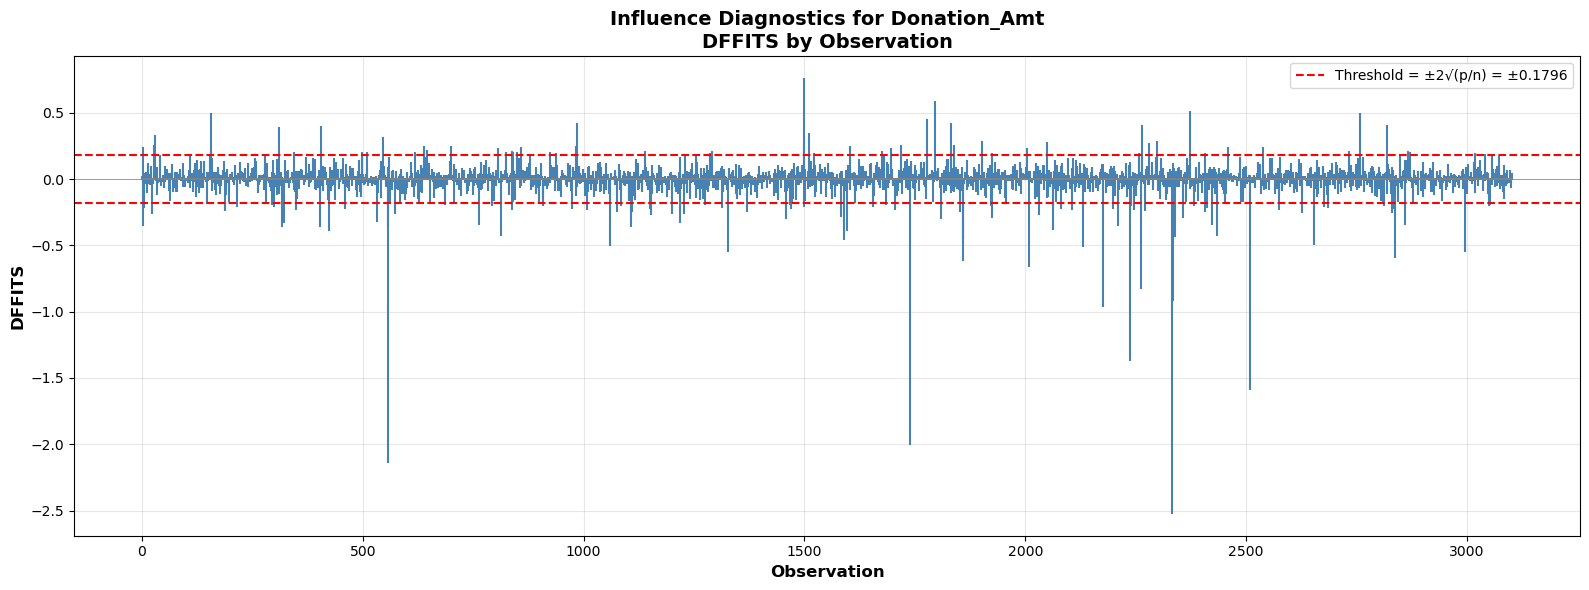


Influential observations (|DFFITS| > 0.1796): 164 of 3101 (5.3%)

Top 10 Most Influential Observations


Observation,DFFITS,Residual,Leverage,Cook's D,Fitted,Actual
2333,-2.5251,-156.6188,0.0662,0.2479,248.7222,92.1034
557,-2.1431,-37.0451,0.3825,0.1833,248.9778,211.9327
1738,-2.0040,-86.9338,0.1219,0.1592,271.1406,184.2068
2508,-1.5921,-100.5734,0.0650,0.1002,229.3284,128.7550
2237,-1.3727,-80.2361,0.0747,0.0748,252.9356,172.6995
2175,-0.9631,-59.8766,0.0673,0.0370,131.5470,71.6704
2334,-0.9192,-80.1604,0.0364,0.0336,208.9154,128.7550
2263,-0.8293,-67.3203,0.0417,0.0274,223.8012,156.4809
1500,0.7613,89.4997,0.0207,0.0230,94.7071,184.2068
2008,-0.6622,-53.5733,0.0420,0.0175,237.7801,184.2068


In [37]:
# Step 5: Influence Diagnostics — DFFITS by Observation
fig, ax = plt.subplots(figsize=(16, 6))

observation_idx = np.arange(1, n + 1)
ax.stem(observation_idx, dffits_vals, linefmt='steelblue', markerfmt=' ', basefmt='gray')

# Threshold: 2 * sqrt(p / n)
dffits_threshold = 2 * np.sqrt(p / n)
ax.axhline(y=dffits_threshold, color='red', linestyle='--', linewidth=1.5,
           label=f'Threshold = ±2√(p/n) = ±{dffits_threshold:.4f}')
ax.axhline(y=-dffits_threshold, color='red', linestyle='--', linewidth=1.5)
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5)

ax.set_xlabel('Observation', fontweight='bold', fontsize=12)
ax.set_ylabel('DFFITS', fontweight='bold', fontsize=12)
ax.set_title('Influence Diagnostics for Donation_Amt\nDFFITS by Observation', fontweight='bold', fontsize=14)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Report influential observations
influential_mask = np.abs(dffits_vals) > dffits_threshold
n_influential = influential_mask.sum()
print(f"\nInfluential observations (|DFFITS| > {dffits_threshold:.4f}): {n_influential} of {n} ({n_influential/n*100:.1f}%)")

if n_influential > 0:
    top_influential = pd.DataFrame({
        'Observation': observation_idx[influential_mask],
        'DFFITS': dffits_vals[influential_mask],
        'Residual': residuals.values[influential_mask],
        'Leverage': leverage[influential_mask],
        "Cook's D": cooks_d[influential_mask],
        'Fitted': fitted_values.values[influential_mask],
        'Actual': y.values[influential_mask]
    }).sort_values('DFFITS', key=abs, ascending=False).head(10)

    display_styled_table(
        top_influential.round(4),
        title="Top 10 Most Influential Observations",
        header_color=TABLE_COLORS['red'],
        font_size="11px"
    )

In [38]:
# 📊 READOUT: Influence Diagnostics — DFFITS
# Use .values arrays to avoid pandas label-vs-position index mismatch
dffits_arr   = dffits_vals if isinstance(dffits_vals, np.ndarray) else dffits_vals.values
cooks_arr_d  = cooks_d if isinstance(cooks_d, np.ndarray) else cooks_d.values
y_arr_d      = y.values
fitted_arr_d = fitted_values.values
resid_arr_d  = residuals.values

print("=" * 120)
print("📊 READOUT: INFLUENCE DIAGNOSTICS — DFFITS")
print("=" * 120)

# Identify the single most influential observation
max_dffits_pos = np.argmax(np.abs(dffits_arr))
max_dffits_val = dffits_arr[max_dffits_pos]
max_dffits_obs = max_dffits_pos + 1
max_actual     = y_arr_d[max_dffits_pos]
max_predicted  = fitted_arr_d[max_dffits_pos]
max_resid      = resid_arr_d[max_dffits_pos]
max_cooksd     = cooks_arr_d[max_dffits_pos]

print(f"\n  DFFITS threshold = ±2√(p/n) = ±{dffits_threshold:.4f}")
print(f"  Observations exceeding threshold: {n_influential} out of {n} ({n_influential/n*100:.1f}%)")

print(f"\n  🔴 MOST INFLUENTIAL OBSERVATION:")
print(f"     Observation #{max_dffits_obs}")
print(f"     DFFITS = {max_dffits_val:.4f}  ({abs(max_dffits_val)/dffits_threshold:.1f}x the threshold)")
print(f"     Actual Donation  = ${max_actual:.2f}")
print(f"     Predicted        = ${max_predicted:.2f}")
print(f"     Residual (error) = ${max_resid:.2f}")
print(f"     Cook's D         = {max_cooksd:.4f}")

if max_resid > 0:
    print(f"\n     ➡️  This donor gave ${max_actual:.2f} but the model predicted only ${max_predicted:.2f}.")
    print(f"        The model under-predicted by ${max_resid:.2f}. This single observation pulls the")
    print(f"        regression surface upward more than any other point in the dataset.")
else:
    print(f"\n     ➡️  This donor gave ${max_actual:.2f} but the model predicted ${max_predicted:.2f}.")
    print(f"        The model over-predicted by ${abs(max_resid):.2f}. This observation pulls the")
    print(f"        regression surface downward more than any other point.")

print(f"\n  🟡 WHAT THIS MEANS:")
print(f"     If we removed observation #{max_dffits_obs} and refitted, predicted values would")
print(f"     shift by up to {abs(max_dffits_val):.4f} standard errors. A DFFITS of ±{dffits_threshold:.4f}")
print(f"     is the threshold where an observation starts to materially change the model.")
print(f"\n     {n_influential} observations ({n_influential/n*100:.1f}%) exceed this threshold — ", end='')
if n_influential / n < 0.05:
    print("this is within the expected range (< 5%).")
else:
    print("this is higher than expected and warrants investigation.")

📊 READOUT: INFLUENCE DIAGNOSTICS — DFFITS

  DFFITS threshold = ±2√(p/n) = ±0.1796
  Observations exceeding threshold: 164 out of 3101 (5.3%)

  🔴 MOST INFLUENTIAL OBSERVATION:
     Observation #2333
     DFFITS = -2.5251  (14.1x the threshold)
     Actual Donation  = $92.10
     Predicted        = $248.72
     Residual (error) = $-156.62
     Cook's D         = 0.2479

     ➡️  This donor gave $92.10 but the model predicted $248.72.
        The model over-predicted by $156.62. This observation pulls the
        regression surface downward more than any other point.

  🟡 WHAT THIS MEANS:
     If we removed observation #2333 and refitted, predicted values would
     shift by up to 2.5251 standard errors. A DFFITS of ±0.1796
     is the threshold where an observation starts to materially change the model.

     164 observations (5.3%) exceed this threshold — this is higher than expected and warrants investigation.


## Step 6: Residual by Regressors for Donation_Amt (Set 1)

### What we're doing:
- Plotting residuals against each individual regressor to check for patterns
- Set 1 covers the core gift-related numeric predictors: GiftCnt36, GiftAvgLast, GiftAvg36, GiftAvgAll, GiftTimeLast, GiftTimeFirst

### Why it matters:
- If the model is correctly specified, residuals should show **no pattern** when plotted against any predictor
- A curved pattern suggests a **non-linear relationship** that the linear model is missing
- A funnel/fan shape indicates **heteroscedasticity** tied to that specific variable

### What to look for:
- Random scatter around the horizontal line at 0 = good
- Curve = consider adding polynomial or transformed terms for that variable
- Fan shape = consider variance-stabilizing transformation (e.g., log)

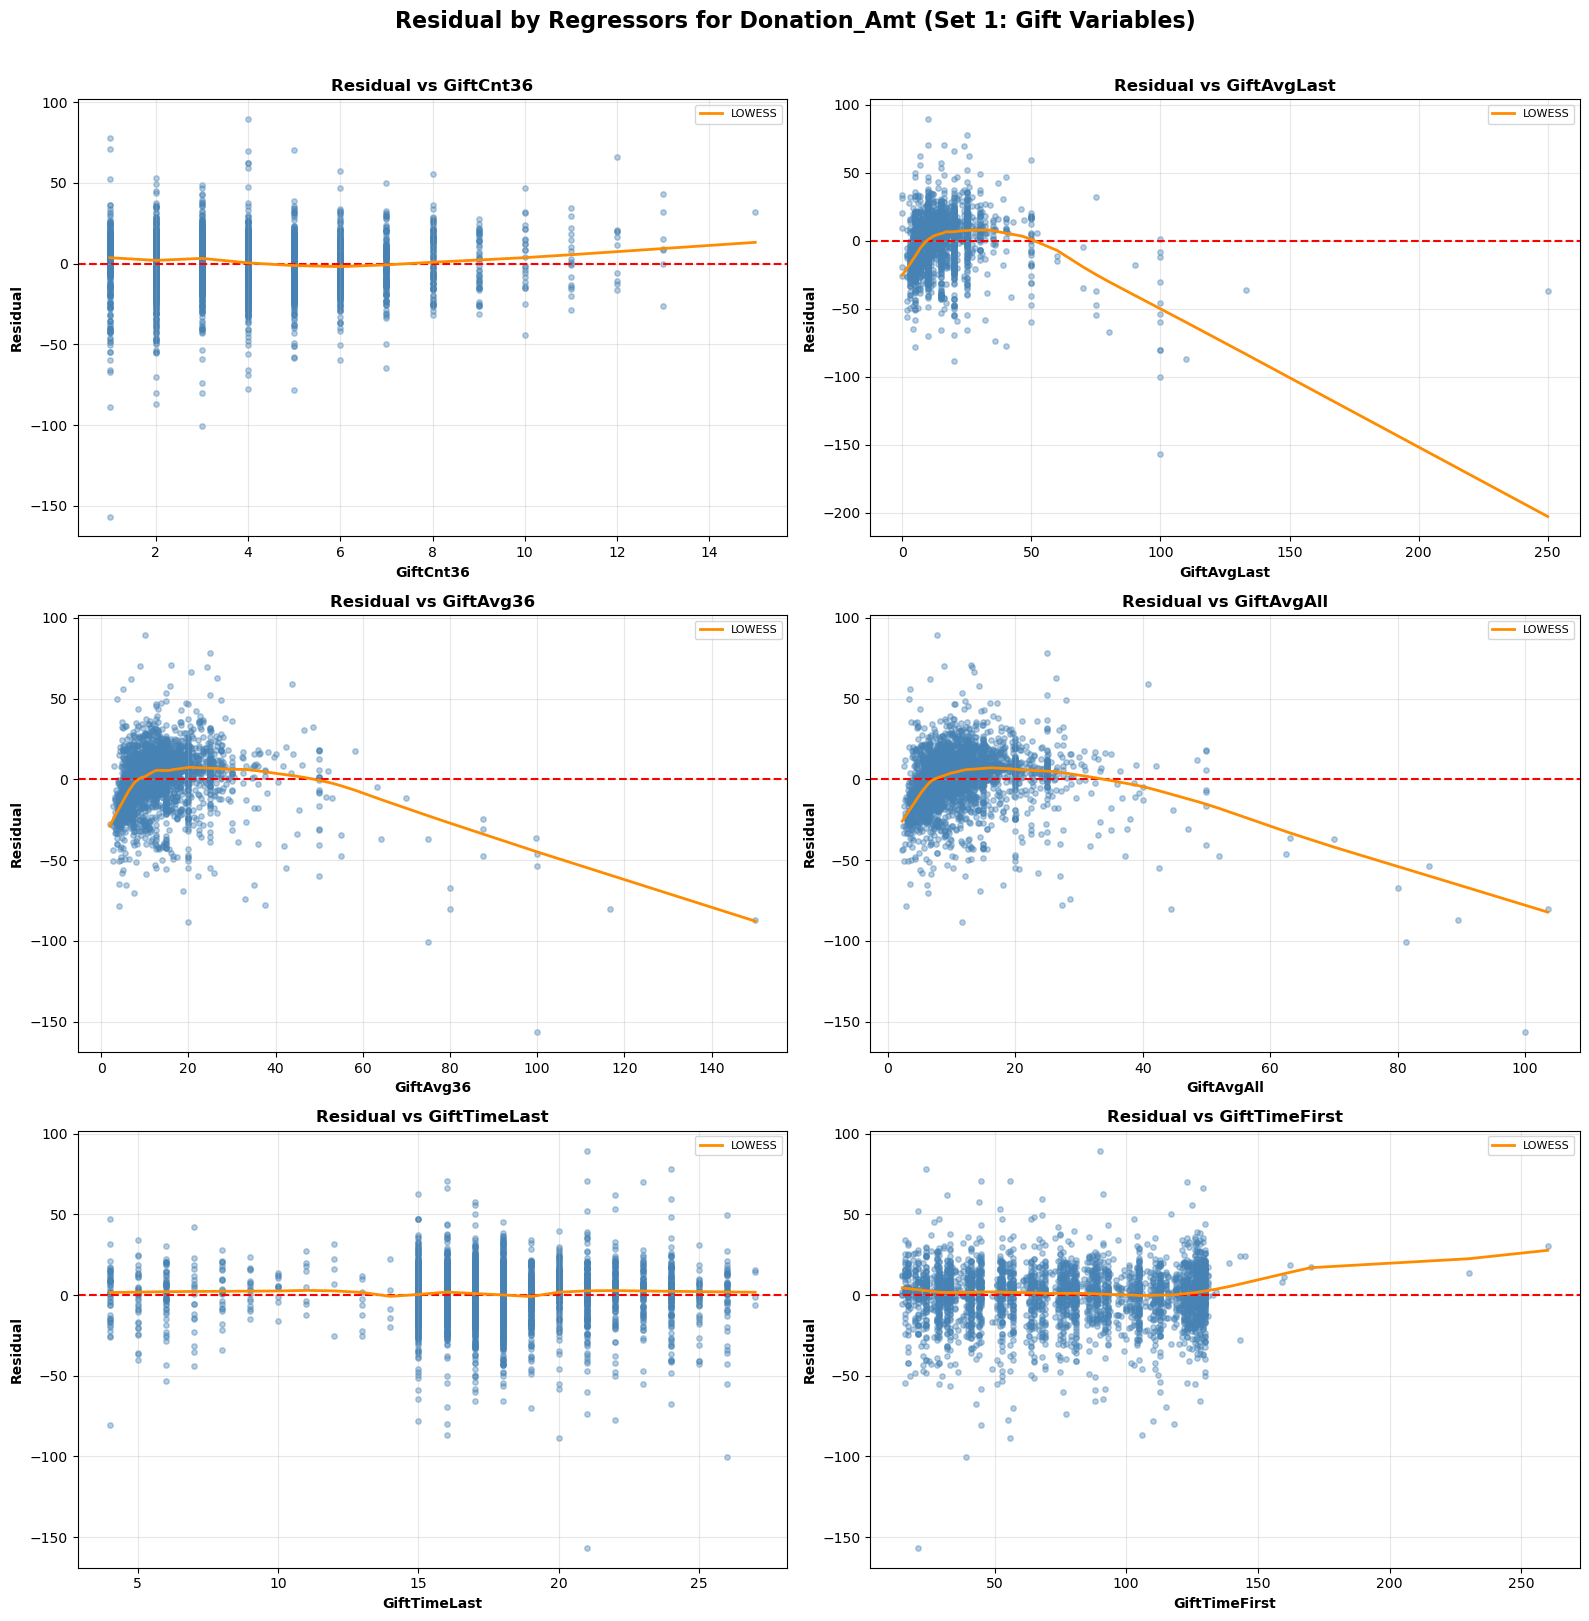

In [39]:
# Step 6: Residual by Regressors — Set 1 (Gift variables)
regressors_set1 = ['GiftCnt36', 'GiftAvgLast', 'GiftAvg36', 'GiftAvgAll', 'GiftTimeLast', 'GiftTimeFirst']

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.suptitle('Residual by Regressors for Donation_Amt (Set 1: Gift Variables)',
             fontsize=16, fontweight='bold', y=1.01)

for idx, var in enumerate(regressors_set1):
    row, col = divmod(idx, 2)
    ax = axes[row, col]

    x_vals = df_encoded.loc[y.index, var]
    ax.scatter(x_vals, residuals, alpha=0.4, s=15, color='steelblue')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)

    # Add LOWESS smoothing line
    try:
        lowess = sm.nonparametric.lowess(residuals, x_vals, frac=0.3)
        ax.plot(lowess[:, 0], lowess[:, 1], color='darkorange', linewidth=2, label='LOWESS')
        ax.legend(fontsize=8)
    except:
        pass

    ax.set_xlabel(var, fontweight='bold')
    ax.set_ylabel('Residual', fontweight='bold')
    ax.set_title(f'Residual vs {var}', fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [40]:
# 📊 READOUT: Residual by Regressors — Set 1 (Gift variables)
print("=" * 120)
print("📊 READOUT: RESIDUAL BY REGRESSORS — SET 1 (GIFT VARIABLES)")
print("=" * 120)
print("\nChecking if the LOWESS curve deviates from zero (red line) for each regressor.")
print("A flat LOWESS near zero = good. A curved or tilted LOWESS = possible non-linearity.\n")

for var in regressors_set1:
    x_vals = df_encoded.loc[y.index, var]
    corr_val = np.corrcoef(x_vals, residuals)[0, 1]
    # Check residual spread at low vs high values
    median_x = x_vals.median()
    resid_low  = residuals[x_vals <= median_x]
    resid_high = residuals[x_vals >  median_x]

    print(f"  {var}:")
    print(f"    Range: {x_vals.min():.1f} to {x_vals.max():.1f} | Median: {median_x:.1f}")
    print(f"    Correlation with residuals: {corr_val:.4f}")
    print(f"    Residual std (low half):  {resid_low.std():.2f}")
    print(f"    Residual std (high half): {resid_high.std():.2f}")
    ratio = resid_high.std() / resid_low.std() if resid_low.std() > 0 else float('inf')
    if ratio > 1.5 or ratio < 0.67:
        print(f"    ⚠️  Spread ratio (high/low) = {ratio:.2f} — possible heteroscedasticity tied to {var}")
    else:
        print(f"    ✅ Spread ratio (high/low) = {ratio:.2f} — residual variance is roughly constant")
    if abs(corr_val) > 0.1:
        direction = 'increases' if corr_val > 0 else 'decreases'
        print(f"    ⚠️  Residual {direction} as {var} grows (r={corr_val:.4f}) — LOWESS curve likely tilted")
    print()

📊 READOUT: RESIDUAL BY REGRESSORS — SET 1 (GIFT VARIABLES)

Checking if the LOWESS curve deviates from zero (red line) for each regressor.
A flat LOWESS near zero = good. A curved or tilted LOWESS = possible non-linearity.

  GiftCnt36:
    Range: 1.0 to 15.0 | Median: 3.0
    Correlation with residuals: -0.0000
    Residual std (low half):  17.37
    Residual std (high half): 17.11
    ✅ Spread ratio (high/low) = 0.98 — residual variance is roughly constant

  GiftAvgLast:
    Range: 0.0 to 250.0 | Median: 13.0
    Correlation with residuals: 0.0000
    Residual std (low half):  15.75
    Residual std (high half): 18.18
    ✅ Spread ratio (high/low) = 1.15 — residual variance is roughly constant

  GiftAvg36:
    Range: 2.0 to 150.0 | Median: 12.0
    Correlation with residuals: 0.0000
    Residual std (low half):  15.64
    Residual std (high half): 18.20
    ✅ Spread ratio (high/low) = 1.16 — residual variance is roughly constant

  GiftAvgAll:
    Range: 2.3 to 103.6 | Median: 9.8


## Step 7: Residual by Regressors for Donation_Amt (Set 2)

### What we're doing:
- Continuing residual-by-regressor analysis for promotion and status variables
- Set 2: PromCntCard12, PromCntCard36, PromCntCardAll, StatusCatStarAll 0, StatusCatStarAll 1, StatusCat96NK A

### Important note on categorical (dummy) variables:
- For binary dummy variables (0/1), the scatter plot will show two vertical strips
- What to look for: whether residual **spread** and **center** differ between the 0 and 1 groups
- If the means differ significantly, the dummy variable may need an interaction term

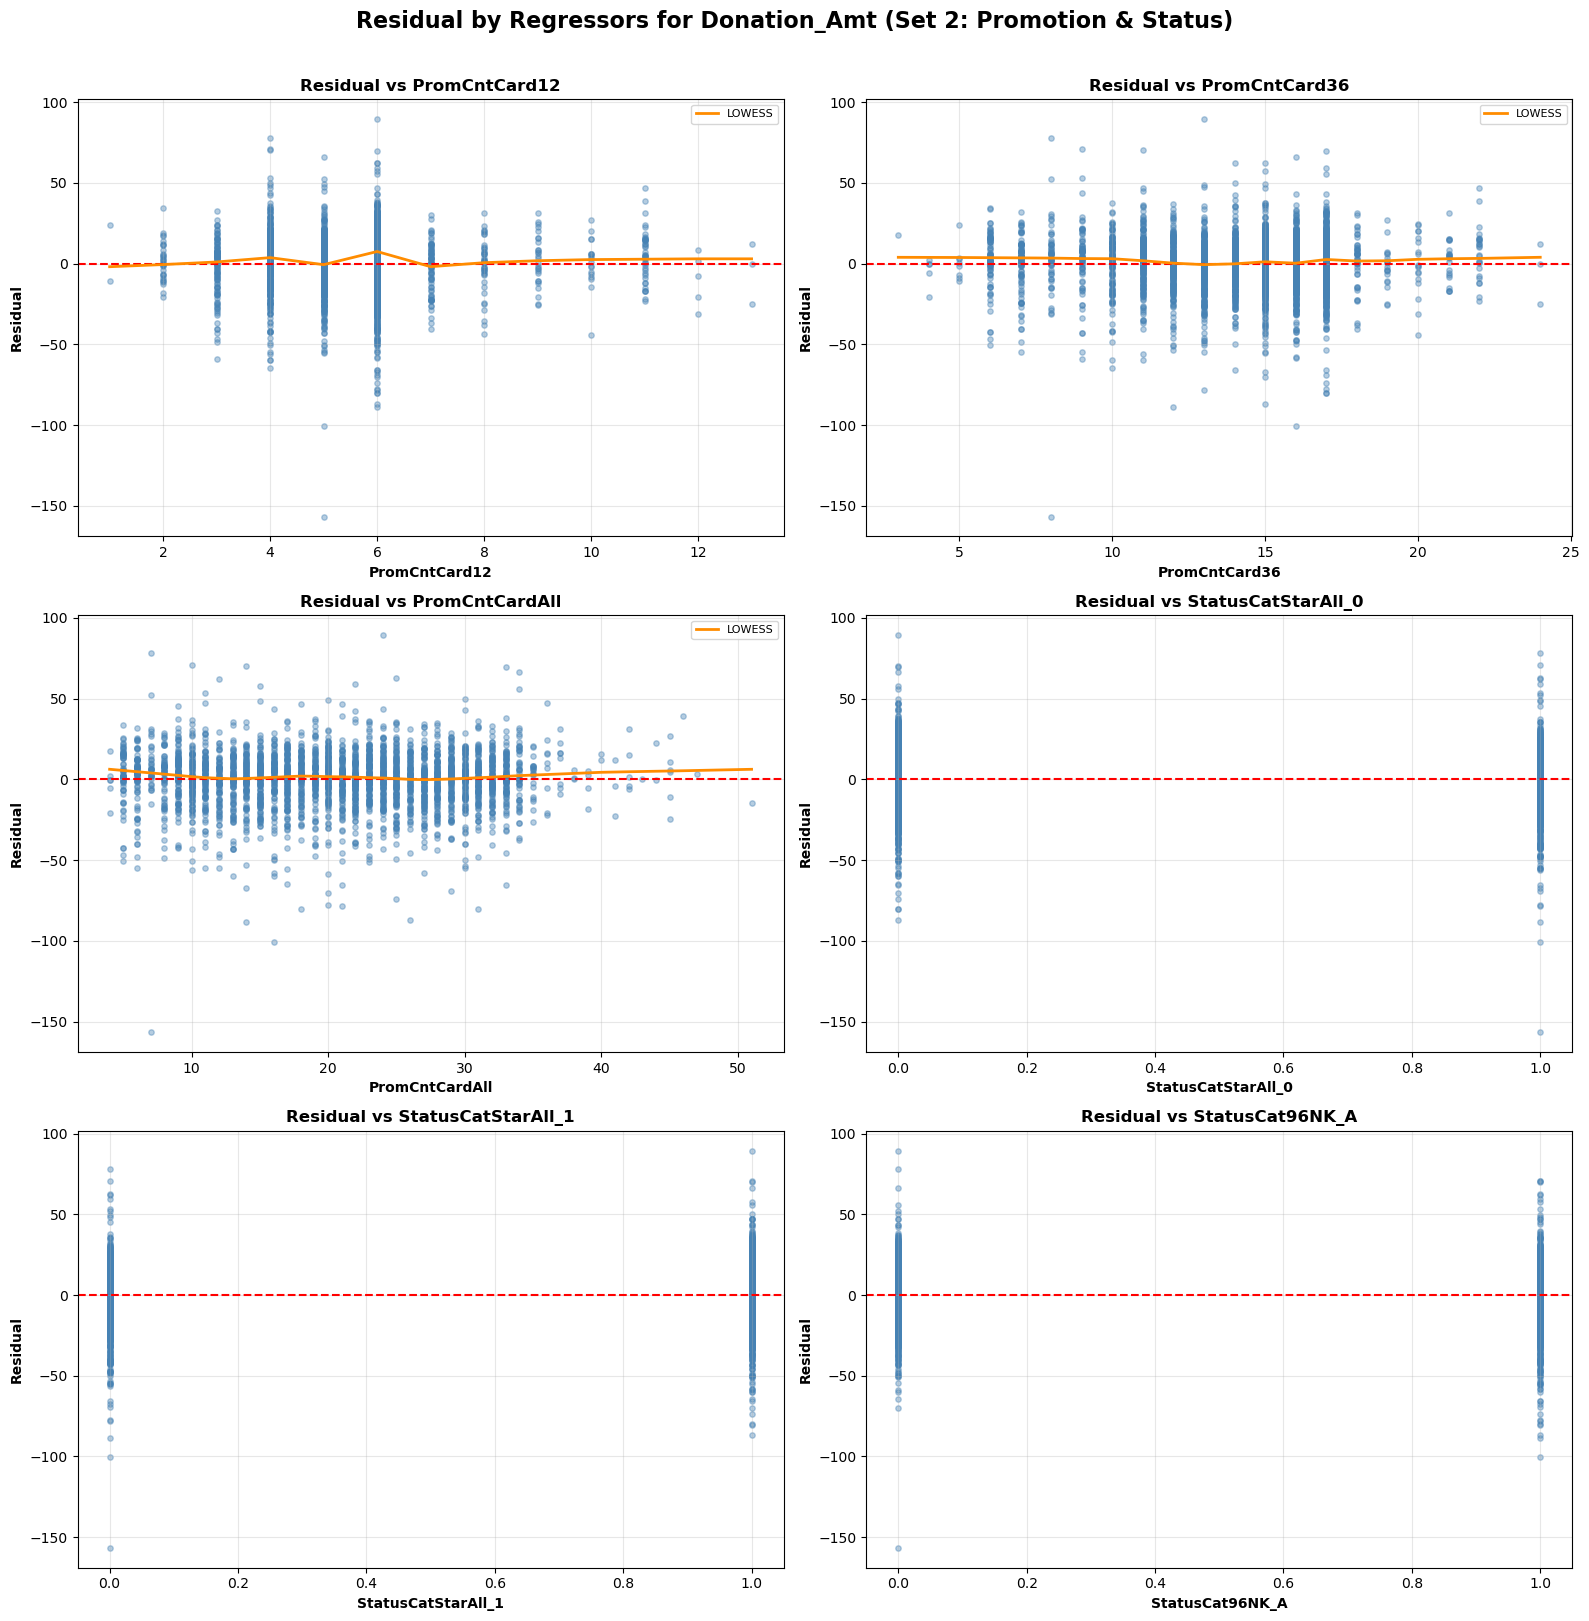

In [41]:
# Step 7: Residual by Regressors — Set 2 (Promotion & Status variables)
# StatusCatStarAll 0 is the baseline (complement of StatusCatStarAll_1.0)
df_diag = df_encoded.loc[y.index].copy()
df_diag['StatusCatStarAll_0'] = 1 - df_diag['StatusCatStarAll_1.0']
df_diag['StatusCatStarAll_1'] = df_diag['StatusCatStarAll_1.0']

# StatusCat96NK_A is the baseline (dropped in one-hot encoding)
# Reconstruct: A = 1 when none of the other StatusCat96NK dummies is 1
status_dummies = [c for c in df_encoded.columns if c.startswith('StatusCat96NK_')]
df_diag['StatusCat96NK_A'] = (df_diag[status_dummies].sum(axis=1) == 0).astype(int)

regressors_set2 = ['PromCntCard12', 'PromCntCard36', 'PromCntCardAll',
                   'StatusCatStarAll_0', 'StatusCatStarAll_1', 'StatusCat96NK_A']

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.suptitle('Residual by Regressors for Donation_Amt (Set 2: Promotion & Status)',
             fontsize=16, fontweight='bold', y=1.01)

for idx, var in enumerate(regressors_set2):
    row, col = divmod(idx, 2)
    ax = axes[row, col]

    x_vals = df_diag[var]
    ax.scatter(x_vals, residuals, alpha=0.4, s=15, color='steelblue')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)

    # Add LOWESS for continuous variables, box-style for binary
    if x_vals.nunique() > 5:
        try:
            lowess = sm.nonparametric.lowess(residuals, x_vals, frac=0.3)
            ax.plot(lowess[:, 0], lowess[:, 1], color='darkorange', linewidth=2, label='LOWESS')
            ax.legend(fontsize=8)
        except:
            pass

    ax.set_xlabel(var, fontweight='bold')
    ax.set_ylabel('Residual', fontweight='bold')
    ax.set_title(f'Residual vs {var}', fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [42]:
# 📊 READOUT: Residual by Regressors — Set 2 (Promotion & Status)
print("=" * 120)
print("📊 READOUT: RESIDUAL BY REGRESSORS — SET 2 (PROMOTION & STATUS)")
print("=" * 120)

for var in regressors_set2:
    x_vals = df_diag[var]
    corr_val = np.corrcoef(x_vals, residuals)[0, 1]

    if x_vals.nunique() <= 2:  # Binary dummy
        resid_0 = residuals[x_vals == 0]
        resid_1 = residuals[x_vals == 1]
        print(f"\n  {var} (binary):")
        print(f"    Group 0: n={len(resid_0):,}, mean residual = {resid_0.mean():.2f}, std = {resid_0.std():.2f}")
        print(f"    Group 1: n={len(resid_1):,}, mean residual = {resid_1.mean():.2f}, std = {resid_1.std():.2f}")
        diff = abs(resid_1.mean() - resid_0.mean())
        if diff > 2:
            print(f"    ⚠️  Mean difference = ${diff:.2f} — residual imbalance between groups")
        else:
            print(f"    ✅ Mean difference = ${diff:.2f} — residuals balanced")
    else:  # Continuous
        print(f"\n  {var} (continuous):")
        print(f"    Range: {x_vals.min():.0f} to {x_vals.max():.0f}")
        print(f"    Correlation with residuals: {corr_val:.4f}")
        if abs(corr_val) > 0.1:
            direction = 'positive' if corr_val > 0 else 'negative'
            print(f"    ⚠️  Residuals have a {direction} trend with {var} (r={corr_val:.4f}).")
            print(f"       This suggests possible non-linearity — consider adding {var}².")
        else:
            print(f"    ✅ Near-zero correlation — no obvious pattern. The linear term is adequate.")

print("\n" + "-" * 120)
print("INTERPRETATION")
print("-" * 120)
print("  For continuous variables: non-zero correlation with residuals signals the LOWESS curve")
print("  deviating from the horizontal red line, meaning the linear relationship may be insufficient.")
print("  For binary dummies: different residual means between group 0 and 1 may suggest interactions.")

📊 READOUT: RESIDUAL BY REGRESSORS — SET 2 (PROMOTION & STATUS)

  PromCntCard12 (continuous):
    Range: 1 to 13
    Correlation with residuals: 0.0000
    ✅ Near-zero correlation — no obvious pattern. The linear term is adequate.

  PromCntCard36 (continuous):
    Range: 3 to 24
    Correlation with residuals: 0.0000
    ✅ Near-zero correlation — no obvious pattern. The linear term is adequate.

  PromCntCardAll (continuous):
    Range: 4 to 51
    Correlation with residuals: 0.0000
    ✅ Near-zero correlation — no obvious pattern. The linear term is adequate.

  StatusCatStarAll_0 (binary):
    Group 0: n=1,987, mean residual = 0.00, std = 16.70
    Group 1: n=1,114, mean residual = 0.00, std = 18.23
    ✅ Mean difference = $0.00 — residuals balanced

  StatusCatStarAll_1 (binary):
    Group 0: n=1,114, mean residual = 0.00, std = 18.23
    Group 1: n=1,987, mean residual = 0.00, std = 16.70
    ✅ Mean difference = $0.00 — residuals balanced

  StatusCat96NK_A (binary):
    Group 0: 

## Step 8: Residual by Regressors for Donation_Amt (Set 3)

### What we're doing:
- Final set of residual-by-regressor plots for the remaining StatusCat96NK dummy variables
- Set 3: StatusCat96NK E, StatusCat96NK F, StatusCat96NK L, StatusCat96NK N, StatusCat96NK S

### Interpreting dummy variable residual plots:
- Each plot has just two vertical strips (0 = not in this category, 1 = in this category)
- Compare the **median** and **spread** of residuals between the two groups
- If the 1-group shows noticeably different residual behavior, the model may benefit from an interaction or different functional form for that category

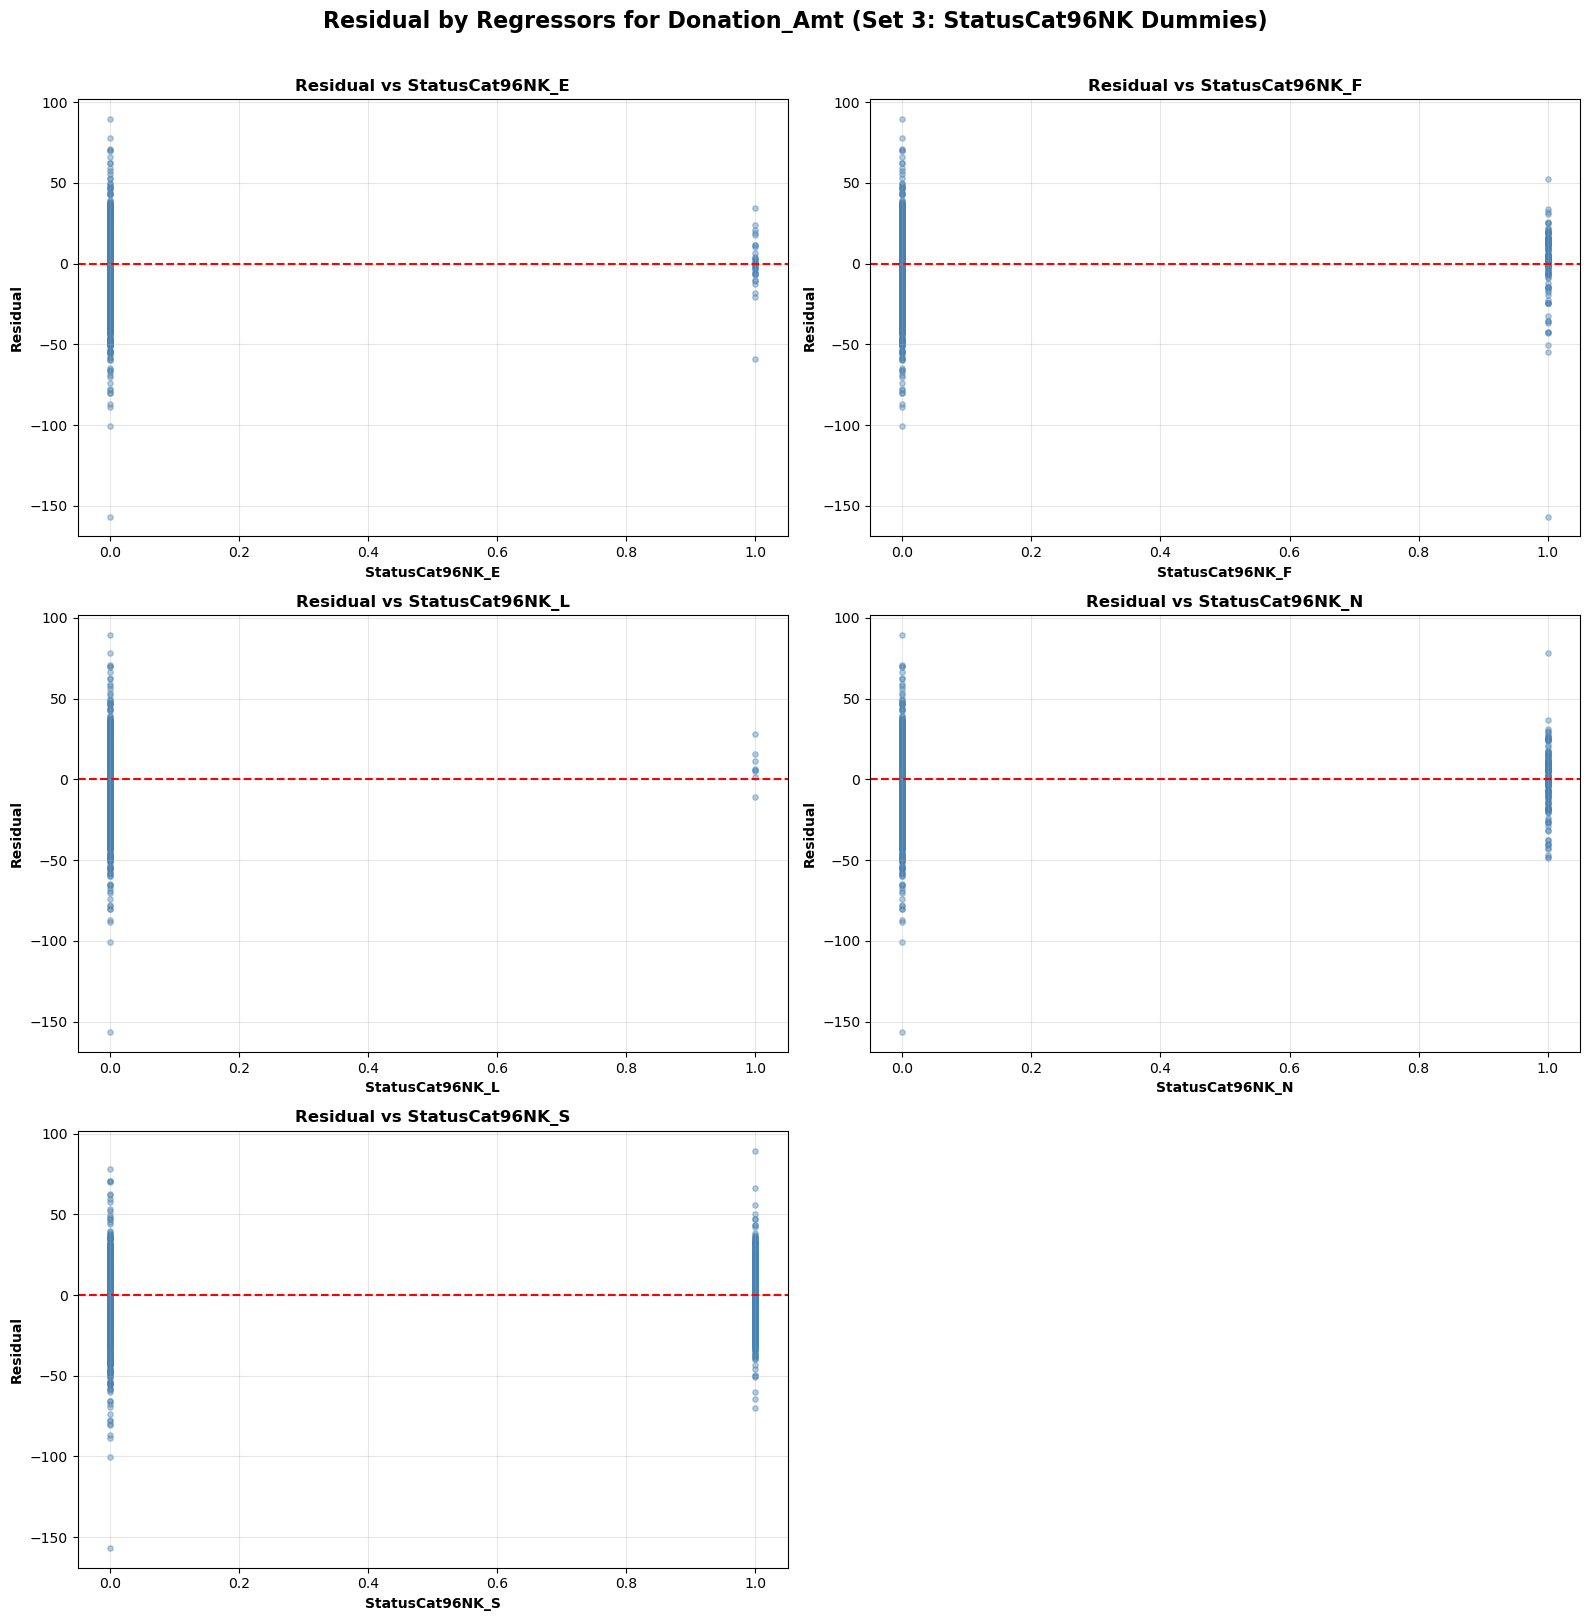


MODEL DIAGNOSTICS SUMMARY

  Observations: 3101
  Parameters:   25
  R²:           0.5462
  Adj R²:       0.5427
  MSE:          297.9119
  AIC:          26516.03

  Influential points (|DFFITS| > 0.1796): 164 (5.3%)
  High-leverage points (h > 0.0161):  472 (15.2%)
  Cook's D > 0.0013: 163 (5.3%)
  |RStudent| > 2: 149 (4.8%)


In [43]:
# Step 8: Residual by Regressors — Set 3 (StatusCat96NK dummies)
regressors_set3 = ['StatusCat96NK_E', 'StatusCat96NK_F', 'StatusCat96NK_L',
                   'StatusCat96NK_N', 'StatusCat96NK_S']

fig, axes = plt.subplots(3, 2, figsize=(16, 16))
fig.suptitle('Residual by Regressors for Donation_Amt (Set 3: StatusCat96NK Dummies)',
             fontsize=16, fontweight='bold', y=1.01)

for idx, var in enumerate(regressors_set3):
    row, col = divmod(idx, 2)
    ax = axes[row, col]

    x_vals = df_diag[var]
    ax.scatter(x_vals, residuals, alpha=0.4, s=15, color='steelblue')
    ax.axhline(y=0, color='red', linestyle='--', linewidth=1.5)

    ax.set_xlabel(var, fontweight='bold')
    ax.set_ylabel('Residual', fontweight='bold')
    ax.set_title(f'Residual vs {var}', fontweight='bold')
    ax.grid(True, alpha=0.3)

# Turn off the empty 6th subplot
axes[2, 1].axis('off')

plt.tight_layout()
plt.show()

# --- Final summary ---
print("\n" + "=" * 120)
print("MODEL DIAGNOSTICS SUMMARY")
print("=" * 120)
print(f"\n  Observations: {n}")
print(f"  Parameters:   {p}")
print(f"  R²:           {final_model.rsquared:.4f}")
print(f"  Adj R²:       {final_model.rsquared_adj:.4f}")
print(f"  MSE:          {mse:.4f}")
print(f"  AIC:          {final_model.aic:.2f}")
print(f"\n  Influential points (|DFFITS| > {dffits_threshold:.4f}): {influential_mask.sum()} ({influential_mask.sum()/n*100:.1f}%)")
print(f"  High-leverage points (h > {lev_threshold:.4f}):  {(leverage > lev_threshold).sum()} ({(leverage > lev_threshold).sum()/n*100:.1f}%)")
print(f"  Cook's D > {cooks_threshold:.4f}: {(cooks_d > cooks_threshold).sum()} ({(cooks_d > cooks_threshold).sum()/n*100:.1f}%)")
print(f"  |RStudent| > 2: {(np.abs(rstudent) > 2).sum()} ({(np.abs(rstudent) > 2).sum()/n*100:.1f}%)")

In [44]:
# 📊 READOUT: Residual by Regressors — Set 3 (StatusCat96NK dummies)
print("=" * 120)
print("📊 READOUT: RESIDUAL BY REGRESSORS — SET 3 (StatusCat96NK DUMMIES)")
print("=" * 120)

for var in regressors_set3:
    x_vals = df_diag[var]
    resid_when_1 = residuals[x_vals == 1]
    resid_when_0 = residuals[x_vals == 0]
    print(f"\n  {var}:")
    print(f"    Group 0 (not {var.split('_')[-1]}): n={len(resid_when_0)}, mean residual = {resid_when_0.mean():.2f}, std = {resid_when_0.std():.2f}")
    print(f"    Group 1 (is  {var.split('_')[-1]}): n={len(resid_when_1)}, mean residual = {resid_when_1.mean():.2f}, std = {resid_when_1.std():.2f}")
    mean_diff = abs(resid_when_1.mean() - resid_when_0.mean())
    if mean_diff > 2:
        print(f"    ⚠️  Mean residual difference = ${mean_diff:.2f} — the model may be systematically")
        print(f"       over- or under-predicting for {var.split('_')[-1]} donors.")
    else:
        print(f"    ✅ Mean residual difference = ${mean_diff:.2f} — residuals are balanced between groups.")

print("\n" + "-" * 120)
print("INTERPRETATION")
print("-" * 120)
print("  If any StatusCat96NK group shows a large residual mean shift or different spread,")
print("  the model might benefit from interaction terms between StatusCat96NK and other predictors.")
print("  Balanced residuals (means near 0 for both groups) suggest the dummy captures the effect well.")

📊 READOUT: RESIDUAL BY REGRESSORS — SET 3 (StatusCat96NK DUMMIES)

  StatusCat96NK_E:
    Group 0 (not E): n=3067, mean residual = 0.00, std = 17.28
    Group 1 (is  E): n=34, mean residual = 0.00, std = 15.68
    ✅ Mean residual difference = $0.00 — residuals are balanced between groups.

  StatusCat96NK_F:
    Group 0 (not F): n=2961, mean residual = -0.05, std = 17.04
    Group 1 (is  F): n=140, mean residual = 1.05, std = 21.43
    ✅ Mean residual difference = $1.10 — residuals are balanced between groups.

  StatusCat96NK_L:
    Group 0 (not L): n=3093, mean residual = -0.02, std = 17.27
    Group 1 (is  L): n=8, mean residual = 7.82, std = 11.12
    ⚠️  Mean residual difference = $7.84 — the model may be systematically
       over- or under-predicting for L donors.

  StatusCat96NK_N:
    Group 0 (not N): n=2934, mean residual = 0.00, std = 17.21
    Group 1 (is  N): n=167, mean residual = 0.00, std = 18.29
    ✅ Mean residual difference = $0.00 — residuals are balanced between g